### Milestone 3

In [1]:
import pandas as pd

df = pd.read_csv("../processed/cleaned_dataset.csv")

df.head()

,OrderID,OrderDate,CustomerID,CustomerName,ProductID,ProductName,Category,Brand,Quantity,UnitPrice,Discount,TotalAmount,PaymentMethod,OrderStatus,City,Country,SellerID
0,ORD0075722,2022-12-22,CUST006588,Sahil Gupta,P00003,Smartphone Case,Clothing,Zenith,4,298.45,0.05,1144.54,Debit Card,Delivered,Columbus,India,SELL01349
1,ORD0080185,2023-05-12,CUST005827,Pooja Patel,P00032,Board Game,Toys & Games,ReadMore,2,154.48,0.00,341.31,Credit Card,Delivered,Jacksonville,India,SELL00680
2,ORD0019865,2021-09-08,CUST019087,Arjun Kumar,P00014,Drone Mini,Home & Kitchen,Apex,3,400.34,0.05,1243.58,Debit Card,Delivered,Chicago,United States,SELL00556
3,ORD0076700,2023-03-12,CUST000432,Aman Kumar,P00034,Desk Organizer,Books,Apex,1,175.53,0.10,175.42,Debit Card,Shipped,Houston,United States,SELL00299
4,ORD0092992,2022-09-10,CUST011736,Aarav Sharma,P00016,Air Fryer,Books,ReadMore,5,190.37,0.00,1077.22,Credit Card,Delivered,Charlotte,United States,SELL01625


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 17 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   OrderID        10000 non-null  object 
 1   OrderDate      10000 non-null  object 
 2   CustomerID     10000 non-null  object 
 3   CustomerName   10000 non-null  object 
 4   ProductID      10000 non-null  object 
 5   ProductName    10000 non-null  object 
 6   Category       10000 non-null  object 
 7   Brand          10000 non-null  object 
 8   Quantity       10000 non-null  int64  
 9   UnitPrice      10000 non-null  float64
 10  Discount       10000 non-null  float64
 11  TotalAmount    10000 non-null  float64
 12  PaymentMethod  10000 non-null  object 
 13  OrderStatus    10000 non-null  object 
 14  City           10000 non-null  object 
 15  Country        10000 non-null  object 
 16  SellerID       10000 non-null  object 
dtypes: float64(3), int64(1), object(13)
memory usage: 1

In [3]:
df.isnull().sum()

OrderID          0
OrderDate        0
CustomerID       0
CustomerName     0
ProductID        0
ProductName      0
Category         0
Brand            0
Quantity         0
UnitPrice        0
Discount         0
TotalAmount      0
PaymentMethod    0
OrderStatus      0
City             0
Country          0
SellerID         0
dtype: int64

In [4]:
df["revenue"] = df["TotalAmount"] * df["Quantity"]

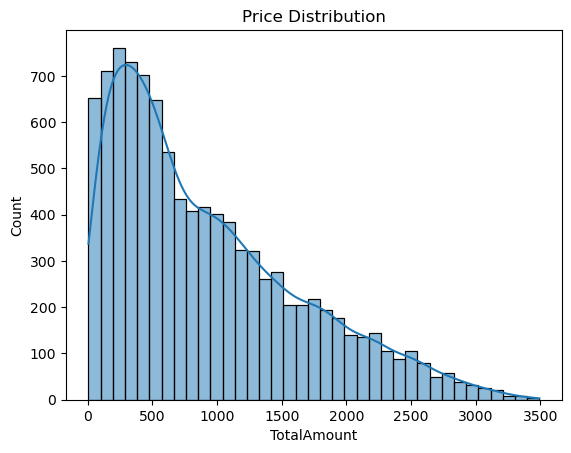

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["TotalAmount"], kde=True)
plt.title("Price Distribution") #showing affordability-focused pricing strategy.
plt.show()

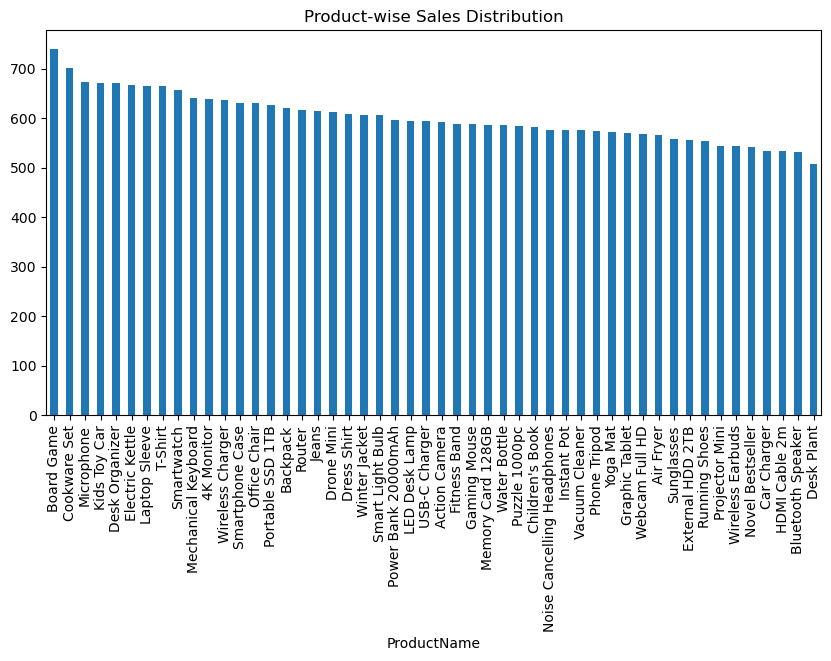

In [6]:
product_sales = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)

product_sales.plot(kind="bar", figsize=(10,5), title="Product-wise Sales Distribution")
plt.show()
#A small number of products contribute to most of the total sales, indicating high-performing items

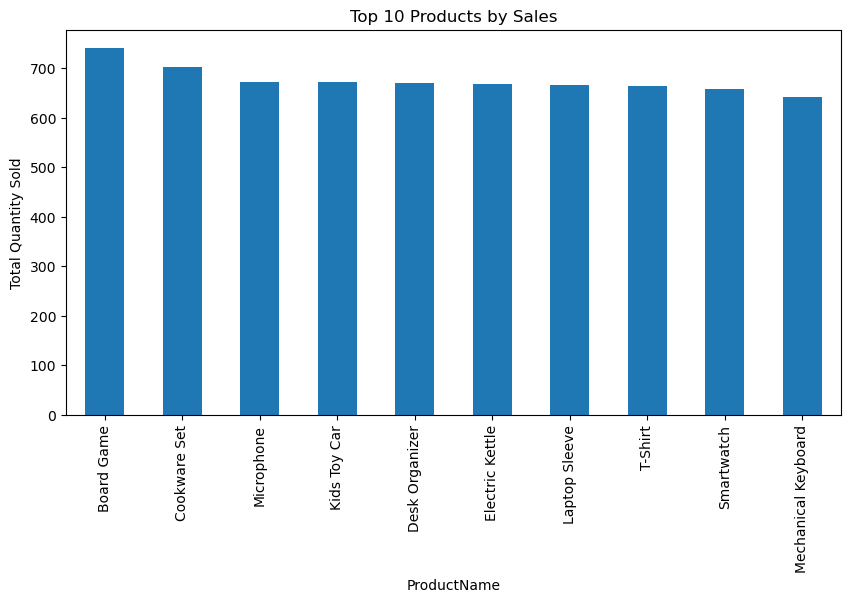

In [7]:
product_sales = df.groupby("ProductName")["Quantity"].sum().sort_values(ascending=False)
#Kuch products high demand generate karte hain. In products par dynamic pricing ka zyada impact hoga.
plt.figure(figsize=(10,5))
product_sales.head(10).plot(kind="bar")
plt.title("Top 10 Products by Sales")
plt.ylabel("Total Quantity Sold")
plt.show()

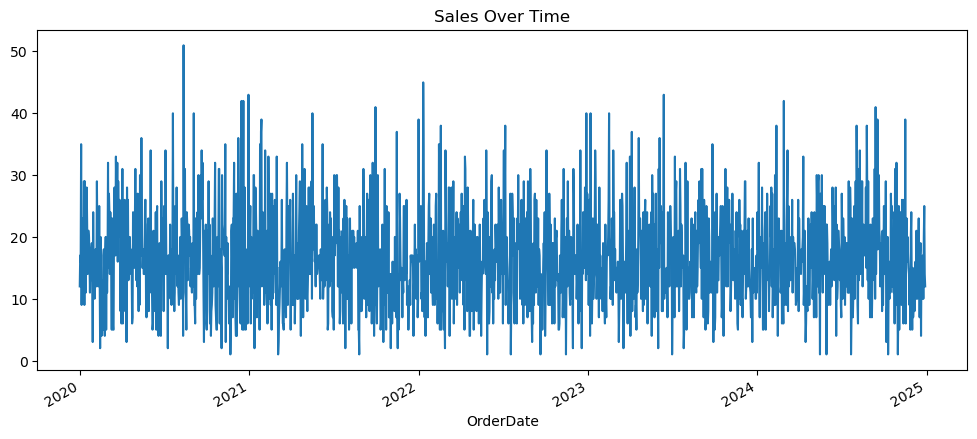

In [8]:
df["OrderDate"] = pd.to_datetime(df["OrderDate"])

daily_sales = df.groupby("OrderDate")["Quantity"].sum()

daily_sales.plot(figsize=(12,5), title="Sales Over Time")
plt.show()
#Demand shows peaks on certain days, indicating seasonal or event-driven demand.

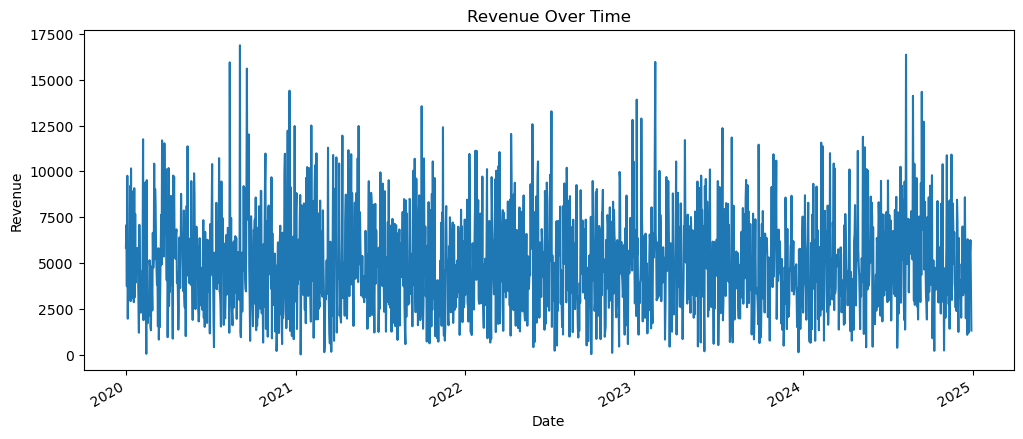

In [9]:
daily_revenue = df.groupby("OrderDate")["TotalAmount"].sum()

plt.figure(figsize=(12,5))
daily_revenue.plot()
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.show()

#Revenue ka trend sales ke saath vary karta hai. Kuch days par kam sales hone ke baad bhi revenue zyada hai, jo high pricing ko indicate karta hai.
#Revenue fluctuates more than demand, showing price changes strongly impact revenue.

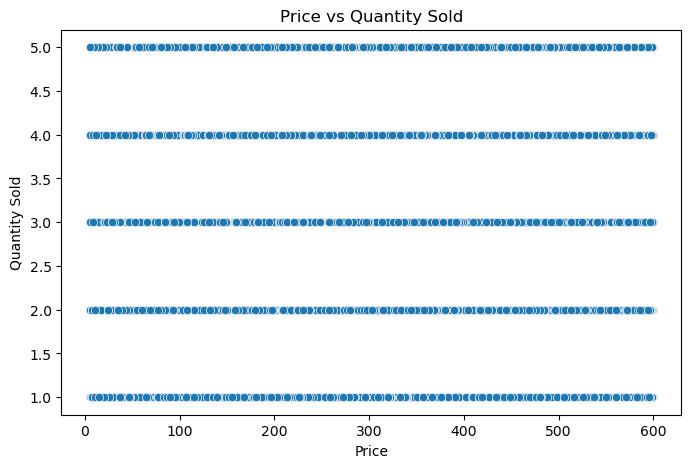

In [10]:
#demand elasticity (core of dynamic pricing)
import seaborn as sns

plt.figure(figsize=(8,5))
sns.scatterplot(x="UnitPrice", y="Quantity", data=df)
plt.title("Price vs Quantity Sold")
plt.xlabel("Price")
plt.ylabel("Quantity Sold")
plt.show()

#As price increases, quantity sold generally decreases, indicating price sensitivity for some products.

In [11]:
#Products were segmented based on demand and price levels to apply different pricing strategies.
df["demand_category"] = pd.qcut(df["Quantity"], q=3, labels=["Low Demand", "Medium Demand", "High Demand"])
df["price_category"] = pd.qcut(df["UnitPrice"], q=3, labels=["Low Price", "Medium Price", "High Price"])

df[["ProductName", "demand_category", "price_category"]].head()

,ProductName,demand_category,price_category
0,Smartphone Case,Medium Demand,Medium Price
1,Board Game,Low Demand,Low Price
2,Drone Mini,Medium Demand,Medium Price
3,Desk Organizer,Low Demand,Low Price
4,Air Fryer,High Demand,Low Price


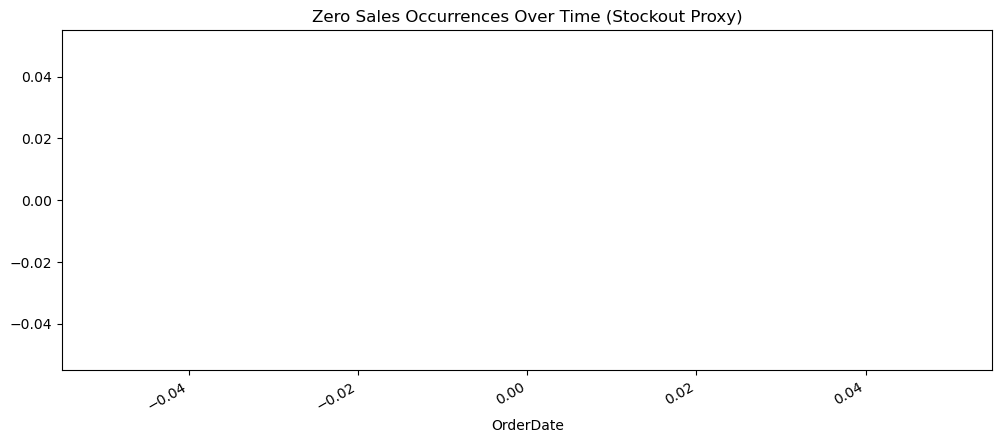

In [12]:
zero_sales = df[df["Quantity"] == 0]

zero_sales.groupby("OrderDate")["Quantity"].count().plot(
    figsize=(12,5), 
    title="Zero Sales Occurrences Over Time (Stockout Proxy)"
)
plt.show()